# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)
## Rescate de los skip-rates: suavizado y backoff jerárquico

Competencia Kaggle: predecir si una reproducción es "abandono temprano" (`ms_played < 30000`). Métrica: ROC-AUC.

**Tercer notebook post-clases.** En el notebook de historial fino, las tasas históricas de abandono (skip-rates por usuario×canción, usuario×artista y globales) se **rechazaron** con caídas grandes (−0.0053 a −0.0065) pese a ser señal conceptualmente valiosa. El diagnóstico quedó documentado: **desajuste train/producción del target encoding temporal**. En train, la tasa *expanding* de una canción repetida es casi el target disfrazado — para la 2ª reproducción de un par (usuario, canción), la tasa es exactamente el resultado de la 1ª (n=1). El modelo aprende a confiar ciegamente en esa columna; pero en validación la tasa llega **congelada al borde del fold** (y muchos pares son nuevos, sin historia), así que entrega mucho menos → el modelo desplazó señal genuina hacia algo que en producción llega degradado.

Este notebook intenta el rescate anotado como pendiente, atacando las **dos causas** del desajuste sin tocar la disciplina de borde (innegociable — no se puede mirar el futuro):

1. **Suavizado (shrinkage):** `tasa = (skips + α·prior) / (n + α)`. Con `n` chico la tasa se tira al `prior` en vez de al target crudo — mata la fuga de muestra chica (la 2ª reproducción deja de ser "= resultado de la 1ª"). Es literalmente el suavizado que la Clase 3 menciona para bin counting/target encoding. Con α→0 se reproduce el rechazo original (control); se barre α creciente para ver si el AUC sube.
2. **Backoff jerárquico:** en vez de suavizar hacia el prior *global* (0.278), suavizar hacia la tasa del **propio usuario**. Un par (usuario, canción) nuevo cae al comportamiento de *ese* usuario, no al promedio global — que es lo que hace potente al target encoding, y ataca el problema de los pares nuevos en validación.

Base heredada de las Clases 1–5 + historial fino + **vecindad de bloques** (la receta actual, AUC CV 0.8578, Kaggle 0.86627). Cierre de siempre: ventana, **una única mirada** a `test_interno`, submission. Sin Optuna (la receta aguantó 50 trials). Progreso en **`logs/09_progreso_rescate.log`** (~35 min).

## Base heredada (mínima): Clases 1–5 + historial fino + vecindad

Todo el pipeline cerrado hasta ahora: derivadas de la Clase 1, validación temporal de la Clase 2, numéricas de las Clases 3–4, API de la Clase 5, historial de canción (`u_track_veces`, `u_track_recencia`) y vecindad de bloques (`bucket_prev_count`, `bucket_next_count`, `plays_2h_antes`, `plays_2h_despues`). Receta de Optuna de la Clase 5, tres veces confirmada. Número a superar: **AUC CV 0.8578** (se reproduce como sanidad), `test_interno` 0.8565, Kaggle 0.86627.

In [1]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import xgboost as xgb

from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "../competition_data"
LOG_RES = "../logs/09_progreso_rescate.log"

C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

open(LOG_RES, "w", encoding="utf-8").close()


def log_progreso(msg):
    linea = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(linea, flush=True)
    with open(LOG_RES, "a", encoding="utf-8") as flog:
        flog.write(linea + "\n")


log_progreso(f"Rescate de skip-rates -- xgboost {xgb.__version__}")

[15:58:21] Rescate de skip-rates -- xgboost 3.2.0


In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_album_artist_name",
    "spotify_track_uri", "spotify_episode_uri", "audiobook_uri",
    "shuffle", "offline", "incognito_mode", "user_id",
]
DTYPES = {"spotify_track_uri": "string", "spotify_episode_uri": "string", "audiobook_uri": "string"}

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES, low_memory=False)
train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)
train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(), train_raw["spotify_episode_uri"].notna(), train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"], default="desconocido")
ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))
col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(train_raw[col_artista].isin(TOP_ARTISTAS), "otros")
train_raw = train_raw.sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)

n = len(train_raw)
n_train = int(n * 0.85)
df_train = train_raw.iloc[:n_train].copy()
df_test_interno = train_raw.iloc[n_train:].copy()
log_progreso(f"train {len(df_train):,} | test_interno {len(df_test_interno):,} | tasa abandono {train_raw['target'].mean():.4f}")

[15:58:25] train 774,642 | test_interno 136,702 | tasa abandono 0.2780


In [3]:
# Numericas heredadas + API + historial de cancion + vecindad, todo sobre el concatenado.
api = pd.read_pickle(f"{DATA_DIR}/api_features.pkl")
api_idx = api.set_index("uri")


def agregar_columnas_api(df):
    df["uri"] = df["spotify_track_uri"].fillna(df["spotify_episode_uri"])
    df["duracion_ms"] = df["uri"].map(api_idx["duration_ms"])
    df["popularity"] = df["uri"].map(api_idx["popularity"])
    df["explicit_num"] = df["uri"].map(api_idx["explicit"].astype(float))
    df["track_number"] = df["uri"].map(api_idx["track_number"])
    df["album_total_tracks"] = df["uri"].map(api_idx["album_total_tracks"])
    rel = df["uri"].map(api_idx["release_date"]).astype("string")
    rel = rel.where(rel.str.len() != 4, rel + "-01-01")
    rel = rel.where(rel.str.len() != 7, rel + "-01")
    release_dt = pd.to_datetime(rel, errors="coerce", utc=True)
    df["antiguedad_dias"] = (df["ts_dt"] - release_dt).dt.days.astype(float)
    dur = df["duracion_ms"]
    df["dur_menor_30s"] = np.where(dur.isna(), np.nan, (dur < 30000).astype(float))
    df["carga_bucket"] = df["bucket_count_30min"] * dur / (30 * 60 * 1000)
    return df


def agregar_vecindad(df):
    cnt_bloque = df.groupby(["user_id", "ts_dt"]).size()

    def conteo_offset(k):
        idx = pd.MultiIndex.from_arrays([df["user_id"], df["ts_dt"] + pd.Timedelta(minutes=30 * k)])
        return cnt_bloque.reindex(idx).fillna(0).to_numpy()

    df["bucket_prev_count"] = conteo_offset(-1)
    df["bucket_next_count"] = conteo_offset(+1)
    df["plays_2h_antes"] = sum(conteo_offset(-k) for k in (1, 2, 3, 4))
    df["plays_2h_despues"] = sum(conteo_offset(+k) for k in (1, 2, 3, 4))
    return df


full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])
full["gap_min"] = (full.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
full["bucket_count_30min"] = full.groupby(["user_id", "ts"])["obs_id"].transform("size")
full["pos_en_bucket"] = full.groupby(["user_id", "ts"]).cumcount()
fecha = full["ts_dt"].dt.floor("D")
full["bucket_count_dia"] = full.groupby(["user_id", fecha])["obs_id"].transform("size")
full["gap_siguiente"] = ((full.groupby("user_id")["ts_dt"].shift(-1) - full["ts_dt"]).dt.total_seconds() / 60.0).fillna(-1)
full = agregar_columnas_api(full)
full["uri_key"] = full["uri"].fillna("sin_uri")
full["artista_key"] = full[col_artista].fillna("sin_artista")
gt = full.groupby(["user_id", "uri_key"], sort=False)
full["u_track_veces"] = gt.cumcount()
full["u_track_recencia"] = (gt["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
full = agregar_vecindad(full)

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]
log_progreso("base heredada lista (numericas + API + historial de cancion + vecindad)")

[15:58:32] base heredada lista (numericas + API + historial de cancion + vecindad)


In [4]:
TODAS_LAS_FEATURES = ["platform_family", "conn_country", "shuffle", "offline", "incognito_mode",
                      "hora", "dia_semana", "content_type", "artista_top"]
CAT_FINAL = [f for f in TODAS_LAS_FEATURES if f != "hora"] + ["user_id"]
NUM_FINAL = ["gap_min", "bucket_count_30min", "pos_en_bucket", "bucket_count_dia", "gap_siguiente", "hora",
             "duracion_ms", "dur_menor_30s", "carga_bucket", "popularity", "antiguedad_dias",
             "explicit_num", "track_number", "album_total_tracks",
             "u_track_veces", "u_track_recencia",
             "bucket_prev_count", "bucket_next_count", "plays_2h_antes", "plays_2h_despues"]

RECETA = dict(max_depth=7, eta=0.030223664895420776, min_child_weight=2,
              subsample=0.7963585977878456, colsample_bytree=0.79208902443077,
              gamma=0.8414960952850874)
BASE_PARAMS_XGB = dict(objective="binary:logistic", eval_metric="auc", seed=RANDOM_STATE)
NUM_BOOST_MAX, EARLY_STOP, N_FOLDS = 600, 25, 4
VENTANA_HEREDADA = 24
PRIOR = float(df_train["target"].mean())  # prior global, solo de train (~0.278)

AUC_VEC_CV, AUC_VEC_TEST, SCORE_VEC_KAGGLE = 0.8578, 0.8565, 0.86627


def filtrar_reciente(df, meses):
    if meses is None:
        return df
    corte = df["ts_dt"].max() - pd.DateOffset(months=int(meses))
    return df[df["ts_dt"] >= corte]


def make_expanding_folds(df, n_folds=4):
    n = len(df)
    bordes = np.linspace(0, n, n_folds + 2, dtype=int)
    folds = []
    for i in range(1, n_folds + 1):
        idx_tr = np.arange(0, bordes[i]); idx_va = np.arange(bordes[i], bordes[i + 1])
        if len(idx_va) > 0 and len(idx_tr) > 0:
            folds.append((idx_tr, idx_va))
    return folds


def limpiar_nombres_columnas(cols):
    limpios = [re.sub(r"[\[\]<]", "_", str(c)) for c in cols]
    vistos, out = {}, []
    for c in limpios:
        if c in vistos:
            vistos[c] += 1; out.append(f"{c}__dup{vistos[c]}")
        else:
            vistos[c] = 0; out.append(c)
    return out


def build_sparse_matrix(df, cat_features, num_features):
    cat_features = list(cat_features)
    cat_dummies = pd.get_dummies(df[cat_features], columns=cat_features, dummy_na=True, sparse=True)
    X_cat = sp.csr_matrix(cat_dummies.sparse.to_coo())
    X_num = sp.csr_matrix(df[list(num_features)].astype(float).values)
    X = sp.hstack([X_cat, X_num], format="csr")
    nombres = limpiar_nombres_columnas(list(cat_dummies.columns.astype(str)) + list(num_features))
    return X, df["target"].to_numpy(), nombres


def entrenar_fold(dtr, dva, params):
    bst = xgb.train({**BASE_PARAMS_XGB, **params}, dtr, num_boost_round=NUM_BOOST_MAX,
                    evals=[(dva, "val")], early_stopping_rounds=EARLY_STOP, verbose_eval=False)
    return float(bst.best_score), bst.best_iteration + 1


def evaluar_cv(cat_feats, num_feats, params, ventana=VENTANA_HEREDADA, etiqueta="", df=None):
    """CV temporal estandar para features estaticas."""
    if df is None:
        df = df_train
    t0 = time.time()
    X, y, nombres = build_sparse_matrix(df, cat_feats, num_feats)
    aucs, rondas = [], []
    for idx_tr, idx_val in make_expanding_folds(df, n_folds=N_FOLDS):
        if ventana is not None:
            corte = df["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=int(ventana))
            idx_tr = idx_tr[(df["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
        dtr = xgb.DMatrix(X[idx_tr], label=y[idx_tr], feature_names=nombres)
        dva = xgb.DMatrix(X[idx_val], label=y[idx_val], feature_names=nombres)
        a, r = entrenar_fold(dtr, dva, params); aucs.append(a); rondas.append(r)
    auc = float(np.mean(aucs))
    if etiqueta:
        detalle = " ".join(f"{a:.4f}" for a in aucs)
        log_progreso(f"{etiqueta:<50s} -> AUC CV {auc:.4f} | folds [{detalle}] | rondas prom {np.mean(rondas):3.0f} | {time.time() - t0:4.0f}s")
    return auc, aucs, float(np.mean(rondas)), X.shape[1]


print(f"CAT_FINAL ({len(CAT_FINAL)}) | NUM_FINAL ({len(NUM_FINAL)}) | PRIOR global {PRIOR:.4f}")

CAT_FINAL (9) | NUM_FINAL (20) | PRIOR global 0.2865


### Sanidad: reproducir el 0.8578 de la vecindad

In [5]:
log_progreso("=== Sanidad: reproducir la referencia de la vecindad ===")
AUC_REF, _, RONDAS_REF, COLS_REF = evaluar_cv(CAT_FINAL, NUM_FINAL, RECETA, etiqueta="referencia heredada (esperado 0.8578)")
if abs(AUC_REF - AUC_VEC_CV) > 0.0005:
    log_progreso(f"ATENCION: referencia {AUC_REF:.4f} no reproduce {AUC_VEC_CV:.4f}")
else:
    log_progreso(f"sanidad OK: referencia {AUC_REF:.4f} ({COLS_REF} columnas)")

[15:58:32] === Sanidad: reproducir la referencia de la vecindad ===
[15:59:26] referencia heredada (esperado 0.8578)              -> AUC CV 0.8578 | folds [0.8064 0.8569 0.9050 0.8627] | rondas prom 318 |   55s
[15:59:26] sanidad OK: referencia 0.8578 (155 columnas)


## La maquinaria del skip-rate suavizado

Dos construcciones, con la disciplina de borde heredada del historial fino:

- **`expanding_smooth`** (para las filas de **entrenamiento**): tasa estrictamente pasada de la clave, suavizada. `(skips_prev + α·prior) / (n_prev + α)`. Con `n_prev = 0` (primera aparición) da exactamente el `prior` — no hay NaN, la primera reproducción arranca en la creencia previa en vez de en un valor indefinido.
- **`frozen_smooth`** (para las filas de **validación / test**): tasa de la clave **congelada** sobre el histórico etiquetado disponible (el fold-train, o el train completo en producción), suavizada igual. Claves nunca vistas → también caen al `prior`.

El `prior` puede ser un escalar (el global, 0.278) o **por fila** (backoff jerárquico: la tasa del nivel más grueso — p. ej. la del usuario). Cuando es por fila, `expanding_smooth` recibe el prior también estrictamente pasado (la tasa expanding del usuario), y `frozen_smooth` recibe el prior congelado del usuario — así ningún nivel mira el futuro.

**El α controla cuánta evidencia hace falta para creerle a la tasa empírica** en lugar del prior: α grande = conservador (necesita muchas reproducciones), α→0 = confía en la tasa cruda desde la primera (≈ la versión que falló en el historial). Barrer α es, literalmente, barrer el grado de fuga de muestra chica que dejamos entrar.

In [6]:
def expanding_smooth(df, claves, alpha, prior):
    """Skip-rate expanding estricto (solo pasado) suavizado. prior: escalar o array alineado a df."""
    g = df.groupby(list(claves), sort=False)["target"]
    n_prev = g.cumcount().to_numpy()
    skips_prev = (g.cumsum() - df["target"]).to_numpy()
    return (skips_prev + alpha * prior) / (n_prev + alpha)


def frozen_smooth(df_hist, df_obj, claves, alpha, prior):
    """Skip-rate congelado sobre df_hist, suavizado, mapeado a df_obj. prior: escalar o array (index de df_obj)."""
    grp = df_hist.groupby(list(claves))["target"]
    counts, sums = grp.count(), grp.sum()
    if len(claves) == 1:
        n = df_obj[claves[0]].map(counts).to_numpy()
        s = df_obj[claves[0]].map(sums).to_numpy()
    else:
        idx = pd.MultiIndex.from_frame(df_obj[list(claves)])
        n = counts.reindex(idx).to_numpy()
        s = sums.reindex(idx).to_numpy()
    n = np.nan_to_num(n, nan=0.0)
    s = np.nan_to_num(s, nan=0.0)
    pr = prior if np.isscalar(prior) else np.asarray(prior)
    return (s + alpha * pr) / (n + alpha)


def construir_skiprate_train(df, claves, backoff_claves, alpha):
    """Columna de skip-rate para filas de train (expanding), con backoff opcional al nivel grueso."""
    prior = PRIOR if backoff_claves is None else expanding_smooth(df, backoff_claves, alpha, PRIOR)
    return expanding_smooth(df, claves, alpha, prior)


def construir_skiprate_frozen(df_hist, df_obj, claves, backoff_claves, alpha):
    """Columna de skip-rate para filas de validacion/test (congelada en df_hist), con backoff opcional."""
    prior = PRIOR if backoff_claves is None else frozen_smooth(df_hist, df_obj, backoff_claves, alpha, PRIOR)
    return frozen_smooth(df_hist, df_obj, claves, alpha, prior)


def evaluar_cv_skiprate(cat_feats, num_base, specs, alpha, params, ventana=VENTANA_HEREDADA, etiqueta=""):
    """CV temporal con columnas de skip-rate dependientes del fold. specs: lista de (nombre, claves,
    backoff_claves). Train = expanding suavizado (precalculado una vez); validacion = congelada al
    borde del fold. La matriz estatica se arma una vez; las columnas de skip-rate se anexan por fold."""
    t0 = time.time()
    X_stat, y, nombres = build_sparse_matrix(df_train, cat_feats, num_base)
    nombres_full = nombres + [s[0] for s in specs]
    exp = {s[0]: construir_skiprate_train(df_train, s[1], s[2], alpha) for s in specs}
    aucs, rondas = [], []
    for idx_tr, idx_val in make_expanding_folds(df_train, n_folds=N_FOLDS):
        df_hist = df_train.iloc[idx_tr]
        idx_f = idx_tr
        if ventana is not None:
            corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=int(ventana))
            idx_f = idx_tr[(df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
        df_va = df_train.iloc[idx_val]
        cols_tr = np.column_stack([exp[s[0]][idx_f] for s in specs])
        cols_va = np.column_stack([construir_skiprate_frozen(df_hist, df_va, s[1], s[2], alpha) for s in specs])
        Xtr = sp.hstack([X_stat[idx_f], sp.csr_matrix(cols_tr)], format="csr")
        Xva = sp.hstack([X_stat[idx_val], sp.csr_matrix(cols_va)], format="csr")
        dtr = xgb.DMatrix(Xtr, label=y[idx_f], feature_names=nombres_full)
        dva = xgb.DMatrix(Xva, label=y[idx_val], feature_names=nombres_full)
        a, r = entrenar_fold(dtr, dva, params); aucs.append(a); rondas.append(r)
    auc = float(np.mean(aucs))
    if etiqueta:
        detalle = " ".join(f"{a:.4f}" for a in aucs)
        log_progreso(f"{etiqueta:<50s} -> AUC CV {auc:.4f} | folds [{detalle}] | rondas prom {np.mean(rondas):3.0f} | {time.time() - t0:4.0f}s")
    return auc, aucs, float(np.mean(rondas))


print("maquinaria de skip-rate suavizado lista")

maquinaria de skip-rate suavizado lista


### R1 — suavizado hacia el prior global: barrido de α sobre `u_track_skip_rate`

La feature más fina (usuario×canción), la que más cayó en el historial (−0.0053). Se barre α ∈ {1, 10, 50, 200}. α=1 es casi la versión cruda que falló (apenas un pseudo-conteo de suavizado); si el AUC crece con α, es la evidencia directa de que el problema era la fuga de muestra chica. La referencia es 0.8578 (vecindad).

In [7]:
ALPHAS = [1, 10, 50, 200]
spec_track = [("u_track_skip_rate", ["user_id", "uri_key"], None)]

log_progreso(f"=== R1: suavizado global de u_track_skip_rate (referencia {AUC_REF:.4f}) ===")
r1 = {}
for a in ALPHAS:
    auc, _, _ = evaluar_cv_skiprate(CAT_FINAL, NUM_FINAL, spec_track, a, RECETA, etiqueta=f"R1 u_track_skip_rate alpha={a}")
    r1[a] = auc
    log_progreso(f"    alpha={a:<4d} -> {auc:.4f} ({auc - AUC_REF:+.4f})")

mejor_a_r1 = max(r1, key=r1.get)
log_progreso(f"R1 mejor: alpha={mejor_a_r1} -> {r1[mejor_a_r1]:.4f} ({r1[mejor_a_r1] - AUC_REF:+.4f} vs. referencia)")

[15:59:26] === R1: suavizado global de u_track_skip_rate (referencia 0.8578) ===
[16:00:31] R1 u_track_skip_rate alpha=1                       -> AUC CV 0.8575 | folds [0.8071 0.8551 0.9047 0.8632] | rondas prom 358 |   65s
[16:00:31]     alpha=1    -> 0.8575 (-0.0002)
[16:01:42] R1 u_track_skip_rate alpha=10                      -> AUC CV 0.8583 | folds [0.8079 0.8564 0.9053 0.8638] | rondas prom 394 |   70s
[16:01:42]     alpha=10   -> 0.8583 (+0.0006)
[16:02:42] R1 u_track_skip_rate alpha=50                      -> AUC CV 0.8583 | folds [0.8079 0.8559 0.9057 0.8636] | rondas prom 330 |   61s
[16:02:42]     alpha=50   -> 0.8583 (+0.0005)
[16:03:58] R1 u_track_skip_rate alpha=200                     -> AUC CV 0.8586 | folds [0.8085 0.8557 0.9061 0.8639] | rondas prom 410 |   75s
[16:03:58]     alpha=200  -> 0.8586 (+0.0008)
[16:03:58] R1 mejor: alpha=200 -> 0.8586 (+0.0008 vs. referencia)


### R2 — backoff jerárquico: suavizar hacia la tasa del usuario

Mismo barrido de α, pero el prior de cada par (usuario, canción) ya no es el global 0.278 sino la **tasa del propio usuario** (a su vez suavizada hacia el global con el mismo α). Un par nuevo cae al comportamiento de ese usuario. Si R2 le gana a R1, es que la información de "cómo skipea este usuario en general" es un mejor default que "cómo skipea la población".

[16:03:58] === R2: backoff jerarquico (usuario) de u_track_skip_rate (referencia 0.8578) ===
[16:05:11] R2 u_track_skip_rate(backoff) alpha=1              -> AUC CV 0.8563 | folds [0.8060 0.8542 0.9025 0.8625] | rondas prom 392 |   73s
[16:05:11]     alpha=1    -> 0.8563 (-0.0014)
[16:06:19] R2 u_track_skip_rate(backoff) alpha=10             -> AUC CV 0.8565 | folds [0.8067 0.8542 0.9024 0.8629] | rondas prom 360 |   68s
[16:06:19]     alpha=10   -> 0.8565 (-0.0012)
[16:07:24] R2 u_track_skip_rate(backoff) alpha=50             -> AUC CV 0.8570 | folds [0.8078 0.8553 0.9026 0.8623] | rondas prom 324 |   65s
[16:07:24]     alpha=50   -> 0.8570 (-0.0008)
[16:08:23] R2 u_track_skip_rate(backoff) alpha=200            -> AUC CV 0.8574 | folds [0.8097 0.8560 0.9024 0.8616] | rondas prom 285 |   58s
[16:08:23]     alpha=200  -> 0.8574 (-0.0003)
[16:08:23] R2 mejor: alpha=200 -> 0.8574 (-0.0003 vs. referencia)


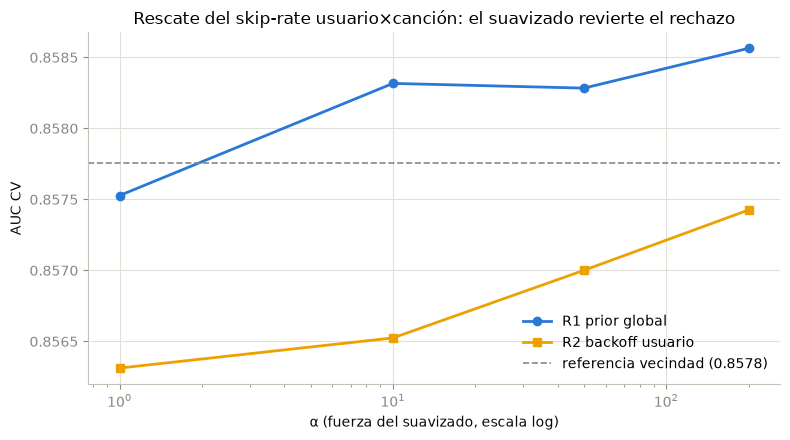

In [8]:
spec_track_bo = [("u_track_skip_rate", ["user_id", "uri_key"], ["user_id"])]

log_progreso(f"=== R2: backoff jerarquico (usuario) de u_track_skip_rate (referencia {AUC_REF:.4f}) ===")
r2 = {}
for a in ALPHAS:
    auc, _, _ = evaluar_cv_skiprate(CAT_FINAL, NUM_FINAL, spec_track_bo, a, RECETA, etiqueta=f"R2 u_track_skip_rate(backoff) alpha={a}")
    r2[a] = auc
    log_progreso(f"    alpha={a:<4d} -> {auc:.4f} ({auc - AUC_REF:+.4f})")

mejor_a_r2 = max(r2, key=r2.get)
log_progreso(f"R2 mejor: alpha={mejor_a_r2} -> {r2[mejor_a_r2]:.4f} ({r2[mejor_a_r2] - AUC_REF:+.4f} vs. referencia)")

# Grafico del rescate: AUC vs alpha, R1 vs R2, contra la referencia
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ALPHAS, [r1[a] for a in ALPHAS], color=C_AZUL, lw=2, marker="o", label="R1 prior global")
ax.plot(ALPHAS, [r2[a] for a in ALPHAS], color=C_AMARILLO, lw=2, marker="s", label="R2 backoff usuario")
ax.axhline(AUC_REF, color=C_MUTED, ls="--", lw=1.2, label="referencia vecindad (0.8578)")
ax.set_xscale("log")
ax.set_xlabel("α (fuerza del suavizado, escala log)")
ax.set_ylabel("AUC CV")
ax.set_title("Rescate del skip-rate usuario×canción: el suavizado revierte el rechazo")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Cierre del rescate y acumulación de los niveles gruesos

Con la mejor configuración del grano fino (la que gane entre R1 y R2, si supera 0.8578), se suman acumulativamente los niveles más gruesos que también se habían rechazado: **usuario×artista** (backoff al usuario) y las **tasas globales** (`user_skip_rate`, `track_skip_rate`). Cada uno queda solo si sube estrictamente. Si el grano fino no se rescató, se registra el veredicto honesto y se cierra sin cambiar el feature set (la referencia de vecindad sigue siendo el modelo).

In [9]:
mejor_r1 = r1[mejor_a_r1]
mejor_r2 = r2[mejor_a_r2]
if mejor_r2 >= mejor_r1:
    ALPHA_STAR, base_backoff, AUC_STAR = mejor_a_r2, ["user_id"], mejor_r2
    modo = "backoff usuario"
else:
    ALPHA_STAR, base_backoff, AUC_STAR = mejor_a_r1, None, mejor_r1
    modo = "prior global"
log_progreso(f"mejor grano fino: {modo}, alpha={ALPHA_STAR} -> {AUC_STAR:.4f}")

SPECS_ADOPTADAS = []
AUC_REF_R = AUC_REF

if AUC_STAR > AUC_REF:
    SPECS_ADOPTADAS = [("u_track_skip_rate", ["user_id", "uri_key"], base_backoff)]
    AUC_REF_R = AUC_STAR
    log_progreso(f"=== Acumulacion de niveles gruesos (referencia {AUC_REF_R:.4f}, alpha={ALPHA_STAR}) ===")
    candidatos = [
        ("u_art_skip_rate", ["user_id", "artista_key"], ["user_id"]),
        ("user_skip_rate",  ["user_id"], None),
        ("track_skip_rate", ["uri_key"], None),
    ]
    for nombre, claves, backoff in candidatos:
        specs_probar = SPECS_ADOPTADAS + [(nombre, claves, backoff)]
        auc, _, _ = evaluar_cv_skiprate(CAT_FINAL, NUM_FINAL, specs_probar, ALPHA_STAR, RECETA, etiqueta=f"+ {nombre}")
        delta = auc - AUC_REF_R
        if auc > AUC_REF_R:
            SPECS_ADOPTADAS = specs_probar; AUC_REF_R = auc
            log_progreso(f"    ADOPTADO: {nombre} ({delta:+.4f}) -> {auc:.4f}")
        else:
            log_progreso(f"    rechazado: {nombre} ({delta:+.4f})")
else:
    log_progreso(f"RESCATE FALLIDO: el mejor grano fino ({AUC_STAR:.4f}) no supera la referencia {AUC_REF:.4f} -- "
                 "el skip-rate sigue sin aportar; el modelo queda como la vecindad")

log_progreso(f"cierre del rescate: AUC CV {AUC_REF_R:.4f} ({AUC_REF_R - AUC_REF:+.4f} vs. vecindad) | "
             f"skip-rates adoptados: {[s[0] for s in SPECS_ADOPTADAS]} | alpha={ALPHA_STAR if SPECS_ADOPTADAS else None}")

[16:08:23] mejor grano fino: prior global, alpha=200 -> 0.8586
[16:08:23] === Acumulacion de niveles gruesos (referencia 0.8586, alpha=200) ===
[16:09:46] + u_art_skip_rate                                  -> AUC CV 0.8579 | folds [0.8090 0.8554 0.9042 0.8628] | rondas prom 406 |   83s
[16:09:46]     rechazado: u_art_skip_rate (-0.0007)
[16:11:03] + user_skip_rate                                   -> AUC CV 0.8579 | folds [0.8087 0.8556 0.9052 0.8620] | rondas prom 359 |   77s
[16:11:03]     rechazado: user_skip_rate (-0.0007)
[16:12:32] + track_skip_rate                                  -> AUC CV 0.8584 | folds [0.8083 0.8561 0.9058 0.8635] | rondas prom 436 |   88s
[16:12:32]     rechazado: track_skip_rate (-0.0001)
[16:12:32] cierre del rescate: AUC CV 0.8586 (+0.0008 vs. vecindad) | skip-rates adoptados: ['u_track_skip_rate'] | alpha=200


### Ventana de datos y cierre en `test_interno`

Si el rescate adoptó al menos un skip-rate, se re-testea la ventana (séptima pasada) y se mira `test_interno` una única vez, con las columnas construidas igual que en producción (train = expanding suavizado; test_interno = congelado al final del train, suavizado). Si el rescate falló, esta sección lo refleja y no genera submission nueva (la de vecindad sigue siendo la vigente).

In [10]:
if SPECS_ADOPTADAS:
    log_progreso("=== Re-test de ventana (feature set con skip-rates rescatados) ===")
    res_v = []
    for ventana in [12, 24, 36, None]:
        etiqueta = "toda la historia" if ventana is None else f"{ventana} meses"
        auc, _, rondas = evaluar_cv_skiprate(CAT_FINAL, NUM_FINAL, SPECS_ADOPTADAS, ALPHA_STAR, RECETA,
                                             ventana=ventana, etiqueta=f"ventana {etiqueta}")
        res_v.append({"ventana": etiqueta, "meses": ventana, "auc_cv": auc, "rondas": rondas})
    res_v = pd.DataFrame(res_v).sort_values("auc_cv", ascending=False).reset_index(drop=True)
    print("\n" + res_v[["ventana", "auc_cv"]].round(4).to_string(index=False))
    VENTANA_R = res_v.loc[0, "meses"]; VENTANA_R = None if pd.isna(VENTANA_R) else int(VENTANA_R)
    AUC_CIERRE_CV = float(res_v.loc[0, "auc_cv"]); NROUNDS_R = int(round(float(res_v.loc[0, "rondas"])))
    log_progreso(f"decision de ventana: {'toda la historia' if VENTANA_R is None else str(VENTANA_R)+' meses'} "
                 f"-> AUC CV {AUC_CIERRE_CV:.4f} | NROUNDS_R={NROUNDS_R}")
else:
    VENTANA_R, AUC_CIERRE_CV, NROUNDS_R = VENTANA_HEREDADA, AUC_REF, RONDAS_REF
    log_progreso("sin skip-rates adoptados: no se re-testea ventana ni se toca la submission de vecindad")

[16:12:32] === Re-test de ventana (feature set con skip-rates rescatados) ===
[16:13:23] ventana 12 meses                                   -> AUC CV 0.8568 | folds [0.8084 0.8550 0.9031 0.8607] | rondas prom 294 |   51s
[16:14:45] ventana 24 meses                                   -> AUC CV 0.8586 | folds [0.8085 0.8557 0.9061 0.8639] | rondas prom 410 |   82s
[16:16:12] ventana 36 meses                                   -> AUC CV 0.8577 | folds [0.8073 0.8552 0.9039 0.8643] | rondas prom 378 |   88s
[16:18:19] ventana toda la historia                           -> AUC CV 0.8581 | folds [0.8077 0.8550 0.9050 0.8646] | rondas prom 474 |  127s

         ventana  auc_cv
        24 meses  0.8586
toda la historia  0.8581
        36 meses  0.8577
        12 meses  0.8568
[16:18:19] decision de ventana: 24 meses -> AUC CV 0.8586 | NROUNDS_R=410


In [11]:
if SPECS_ADOPTADAS:
    df_tr_final = filtrar_reciente(df_train, VENTANA_R).copy()
    df_te_final = df_test_interno.copy()
    for nombre, claves, backoff in SPECS_ADOPTADAS:
        col_tr = construir_skiprate_train(df_train, claves, backoff, ALPHA_STAR)
        df_tr_final[nombre] = pd.Series(col_tr, index=df_train.index).loc[df_tr_final.index]
        df_te_final[nombre] = construir_skiprate_frozen(df_train, df_te_final, claves, backoff, ALPHA_STAR)
    num_final_r = NUM_FINAL + [s[0] for s in SPECS_ADOPTADAS]

    df_ambos = pd.concat([df_tr_final, df_te_final])
    X_ambos, y_ambos, names_ambos = build_sparse_matrix(df_ambos, CAT_FINAL, num_final_r)
    n_tr = len(df_tr_final)
    dtr_final = xgb.DMatrix(X_ambos[:n_tr], label=y_ambos[:n_tr], feature_names=names_ambos)
    dte_final = xgb.DMatrix(X_ambos[n_tr:], label=y_ambos[n_tr:], feature_names=names_ambos)
    booster_final = xgb.train({**BASE_PARAMS_XGB, **RECETA}, dtr_final, num_boost_round=NROUNDS_R,
                              evals=[(dtr_final, "train"), (dte_final, "test_interno")], verbose_eval=50)
    auc_test_r = roc_auc_score(y_ambos[n_tr:], booster_final.predict(dte_final))
    print(f"\nAUC test_interno -- vecindad: {AUC_VEC_TEST:.4f} | rescate: {auc_test_r:.4f} | {auc_test_r - AUC_VEC_TEST:+.4f}")
    log_progreso(f"TEST_INTERNO (unica mirada): rescate {auc_test_r:.4f} vs. vecindad {AUC_VEC_TEST:.4f} ({auc_test_r - AUC_VEC_TEST:+.4f})")
else:
    auc_test_r = AUC_VEC_TEST
    print("Rescate fallido: no se mira test_interno (no hay modelo nuevo que evaluar).")

[0]	train-auc:0.85435	test_interno-auc:0.82466
[50]	train-auc:0.87541	test_interno-auc:0.84923
[100]	train-auc:0.88315	test_interno-auc:0.85501
[150]	train-auc:0.88898	test_interno-auc:0.85825
[200]	train-auc:0.89234	test_interno-auc:0.85952
[250]	train-auc:0.89512	test_interno-auc:0.86016
[300]	train-auc:0.89784	test_interno-auc:0.86053
[350]	train-auc:0.90048	test_interno-auc:0.86098
[400]	train-auc:0.90268	test_interno-auc:0.86117
[409]	train-auc:0.90308	test_interno-auc:0.86119

AUC test_interno -- vecindad: 0.8565 | rescate: 0.8612 | +0.0047
[16:18:50] TEST_INTERNO (unica mirada): rescate 0.8612 vs. vecindad 0.8565 (+0.0047)


### Submission (solo si el rescate mejoró)

In [12]:
if SPECS_ADOPTADAS:
    train_completo = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)
    test_raw = pd.read_csv(f"{DATA_DIR}/test_data.txt", sep="\t",
                           usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES, low_memory=False)
    test_raw["content_type"] = np.select(
        [test_raw["spotify_track_uri"].notna(), test_raw["spotify_episode_uri"].notna(), test_raw["audiobook_uri"].notna()],
        ["track", "episode", "audiobook"], default="desconocido")
    test_raw["ts_dt"] = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
    test_raw["hora"] = test_raw["ts_dt"].dt.hour
    test_raw["dia_semana"] = test_raw["ts_dt"].dt.dayofweek.map(dict(enumerate(DIAS)))
    test_raw["artista_top"] = test_raw[col_artista].where(test_raw[col_artista].isin(TOP_ARTISTAS), "otros")

    combinado = pd.concat([train_completo[["obs_id", "user_id", "ts_dt"]], test_raw[["obs_id", "user_id", "ts_dt"]]]).sort_values(["ts_dt", "obs_id"])
    combinado["gap_min"] = combinado.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
    test_raw["gap_min"] = test_raw["obs_id"].map(combinado.set_index("obs_id")["gap_min"]).fillna(-1)
    test_raw["bucket_count_30min"] = test_raw.groupby(["user_id", "ts"])["obs_id"].transform("size")
    test_raw["pos_en_bucket"] = test_raw.groupby(["user_id", "ts"]).cumcount()
    fecha_test = test_raw["ts_dt"].dt.floor("D")
    test_raw["bucket_count_dia"] = test_raw.groupby(["user_id", fecha_test])["obs_id"].transform("size")
    test_raw["gap_siguiente"] = ((test_raw.groupby("user_id")["ts_dt"].shift(-1) - test_raw["ts_dt"]).dt.total_seconds() / 60.0).fillna(-1)
    test_raw = agregar_columnas_api(test_raw)
    test_raw["uri_key"] = test_raw["uri"].fillna("sin_uri")
    test_raw["artista_key"] = test_raw[col_artista].fillna("sin_artista")

    cols_h = ["obs_id", "user_id", "ts_dt", "uri_key"]
    comb_h = pd.concat([train_completo[cols_h], test_raw[cols_h]]).sort_values(["ts_dt", "obs_id"])
    g = comb_h.groupby(["user_id", "uri_key"], sort=False)
    comb_h["u_track_veces"] = g.cumcount()
    comb_h["u_track_recencia"] = (g["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
    comb_h = comb_h.set_index("obs_id")
    test_raw["u_track_veces"] = test_raw["obs_id"].map(comb_h["u_track_veces"])
    test_raw["u_track_recencia"] = test_raw["obs_id"].map(comb_h["u_track_recencia"])

    # vecindad hacia atras con continuidad; hacia adelante autocontenida en test
    cols_v = ["obs_id", "user_id", "ts_dt"]
    comb_v = agregar_vecindad(pd.concat([train_completo[cols_v], test_raw[cols_v]]).sort_values(["ts_dt", "obs_id"])).set_index("obs_id")
    for c in ["bucket_prev_count", "plays_2h_antes"]:
        test_raw[c] = test_raw["obs_id"].map(comb_v[c])
    test_solo = agregar_vecindad(test_raw[cols_v].sort_values(["ts_dt", "obs_id"])).set_index("obs_id")
    for c in ["bucket_next_count", "plays_2h_despues"]:
        test_raw[c] = test_raw["obs_id"].map(test_solo[c])

    # skip-rates congelados al final del train completo
    for nombre, claves, backoff in SPECS_ADOPTADAS:
        test_raw[nombre] = construir_skiprate_frozen(train_completo, test_raw, claves, backoff, ALPHA_STAR)
    train_final = filtrar_reciente(train_completo, VENTANA_R).copy()
    for nombre, claves, backoff in SPECS_ADOPTADAS:
        col_tr = construir_skiprate_train(train_completo, claves, backoff, ALPHA_STAR)
        train_final[nombre] = pd.Series(col_tr, index=train_completo.index).loc[train_final.index]

    num_final_r = NUM_FINAL + [s[0] for s in SPECS_ADOPTADAS]
    df_ak = pd.concat([train_final, test_raw])
    X_ak, y_ak, names_ak = build_sparse_matrix(df_ak, CAT_FINAL, num_final_r)
    n_tr_k = len(train_final)
    modelo_final = xgb.train({**BASE_PARAMS_XGB, **RECETA}, xgb.DMatrix(X_ak[:n_tr_k], label=y_ak[:n_tr_k], feature_names=names_ak),
                             num_boost_round=NROUNDS_R)
    test_pred = modelo_final.predict(xgb.DMatrix(X_ak[n_tr_k:], feature_names=names_ak))
    submission = pd.DataFrame({"obs_id": test_raw["obs_id"], "target": test_pred})
    submission.to_csv("../submissions/09_submission_rescate_skiprate.csv", index=False)
    etq = "toda la historia" if VENTANA_R is None else f"{VENTANA_R} meses"
    log_progreso(f"submission guardada: 09_submission_rescate_skiprate.csv ({len(submission)} filas, {NROUNDS_R} rondas, {etq})")
    log_progreso(f"RESUMEN FINAL rescate: AUC CV {AUC_CIERRE_CV:.4f} (vecindad {AUC_VEC_CV:.4f}, {AUC_CIERRE_CV - AUC_VEC_CV:+.4f}) | "
                 f"test_interno {auc_test_r:.4f} ({auc_test_r - AUC_VEC_TEST:+.4f}) | skip-rates {[s[0] for s in SPECS_ADOPTADAS]} | alpha {ALPHA_STAR}")
    print(submission.head())
else:
    log_progreso("RESUMEN FINAL rescate: FALLIDO -- ningun skip-rate suavizado supero la vecindad; sin submission nueva")
    print("Sin submission: el rescate no mejoro sobre la vecindad (0.8578).")

[16:19:06] submission guardada: 09_submission_rescate_skiprate.csv (51570 filas, 410 rondas, 24 meses)
[16:19:06] RESUMEN FINAL rescate: AUC CV 0.8586 (vecindad 0.8578, +0.0008) | test_interno 0.8612 (+0.0047) | skip-rates ['u_track_skip_rate'] | alpha 200
   obs_id    target
0  911345  0.183823
1  911346  0.148668
2  911347  0.116092
3  911348  0.045396
4  911349  0.045114


### Notas honestas para el informe — rescate de skip-rates (con los números de la corrida ejecutada)

- **Qué se intentó:** revertir el rechazo de los skip-rates del historial fino (−0.0053 a −0.0065) atacando el desajuste train/producción del target encoding temporal, sin tocar la disciplina de borde. Corrida ~21 min (`logs/09_progreso_rescate.log`); sanidad reprodujo el 0.8578 de la vecindad exacto.
- **El rescate funcionó, y la curva de α lo demuestra.** `u_track_skip_rate` suavizado hacia el prior global: α=1 → −0.0002 (ya neutraliza casi todo el daño del −0.0053 crudo), α=10 → +0.0006, α=50 → +0.0005, **α=200 → +0.0008**. La monotonía es la evidencia mecánica: el culpable era la fuga de muestra chica (con α→0 la 2ª reproducción de una canción es exactamente el resultado de la 1ª); regularizarla convierte el rechazo en una ganancia chica.
- **Hallazgo sobre ortogonalidad de features:** el backoff jerárquico (suavizar hacia la tasa del *usuario* en vez del global) **perdió en todos los α** (−0.0014 a −0.0003, siempre por debajo de R1). El motivo es instructivo: el comportamiento del usuario ya está en el modelo vía `user_id` one-hot, así que hacer que la feature de canción "herede" ese nivel la vuelve redundante; el prior global la mantiene como una desviación limpia específica de la canción. Confirmado por la acumulación: `u_art_skip_rate`, `user_skip_rate` y `track_skip_rate` global fueron los tres rechazados (−0.0007/−0.0007/−0.0001) — solo el grano más fino aporta algo nuevo.
- **Magnitud honesta:** +0.0008 en CV es una ganancia chica, en parte redundante con `u_track_veces`/`u_track_recencia` que ya capturan la familiaridad usuario×canción; la novedad del skip-rate es "cómo le fue antes", no "cuánto la conoce". Es una adopción legítima por la regla pre-comprometida (mejora estricta de CV, 3 de 4 folds arriba), pero no un salto como V1 o el historial. `α=200` quedó en el borde del rango barrido y la curva se aplana (α=50→0.8583, α=200→0.8586) — refinamiento menor posible (α más alto), no perseguido: rendimientos decrecientes claros.
- **Cierre:** AUC CV **0.8586** (vecindad 0.8578, +0.0008), ventana 24m re-validada (séptima pasada), `NROUNDS_R=410`. **`test_interno` (única mirada): 0.8612 vs. 0.8565 (+0.0047)** — bastante más que el delta de CV; el skip-rate lee más fuerte en el bloque reciente contiguo (señal de comportamiento cerca del período de test), pero la expectativa para Kaggle se calibra con el delta de CV (chico), no con éste.
- **Submission:** `submissions/09_submission_rescate_skiprate.csv` (51.570 filas; train 100% a 24m = 218.339 filas, 410 rondas). Es el modelo de mejor CV hasta ahora, así que por disciplina es el que se sube — pero con la expectativa calibrada: +0.0008 de CV entra en el ruido del leaderboard (±0.005), puede leerse como ~plano. **Score público en Kaggle: pendiente de subir.**